<a href="https://www.kaggle.com/code/avikdas567/global-temperature-trends-and-climate-forecasting?scriptVersionId=320770967" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# Global Temperature Trends - Climate Analytics & Forecasting

## Historical Climate Trends & Worldwide Temperature Analytics

This notebook presents a complete end-to-end analysis of worldwide historical temperature data collected across cities, countries, and regions.

The study focuses on:

- Exploratory Data Analysis
- Climate Trend Analysis
- Regional Temperature Comparisons
- Seasonal and Monthly Variability
- Statistical Analysis
- Machine Learning Modeling
- Deep Learning Forecasting using LSTM Networks

The dataset contains daily temperature observations and geographical information that can be used to understand long-term climate behavior and global warming trends.


In [1]:
# IMPORT LIBRARIES

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14,6)

2026-05-20 05:59:07.200473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779256747.614639      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779256747.723849      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779256748.714383      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779256748.714423      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779256748.714426      23 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [2]:
# LOAD DATASET

DATA_PATH = "/kaggle/input/datasets/eshummalik/global-temperature-trends/city_temperature.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2906327, 8)


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9



#  Initial Dataset Exploration


In [3]:
# BASIC INFORMATION

display(df.info())

display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906327 entries, 0 to 2906326
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Region          object 
 1   Country         object 
 2   State           object 
 3   City            object 
 4   Month           int64  
 5   Day             int64  
 6   Year            int64  
 7   AvgTemperature  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 177.4+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,2906327,7,North America,1556681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,2906327,125,US,1455337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1455337,52,Texas,129711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,2906327,321,Springfield,18530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,2906327.0,NaN,NaN,NaN,6.469163,3.456489,1.0,3.0,6.0,9.0,12.0
Day,2906327.0,NaN,NaN,NaN,15.716816,8.800534,0.0,8.0,16.0,23.0,31.0
Year,2906327.0,NaN,NaN,NaN,2006.623909,23.382259,200.0,2001.0,2007.0,2013.0,2020.0
AvgTemperature,2906327.0,NaN,NaN,NaN,56.004921,32.123594,-99.0,45.8,62.5,75.5,110.0



### Observations

- The dataset contains more than 2.9 million records, making it suitable for large-scale climate analytics and machine learning experiments.
- The dataset includes both numerical and categorical variables describing geographical and temporal information.
- Temperature is recorded as a continuous numerical feature.
- The large temporal coverage allows long-term climate trend analysis across multiple regions and countries.


,Missing Values,Percentage
State,1450990,49.925215
Region,0,0.000000
Country,0,0.000000
City,0,0.000000
Month,0,0.000000
Day,0,0.000000
Year,0,0.000000
AvgTemperature,0,0.000000


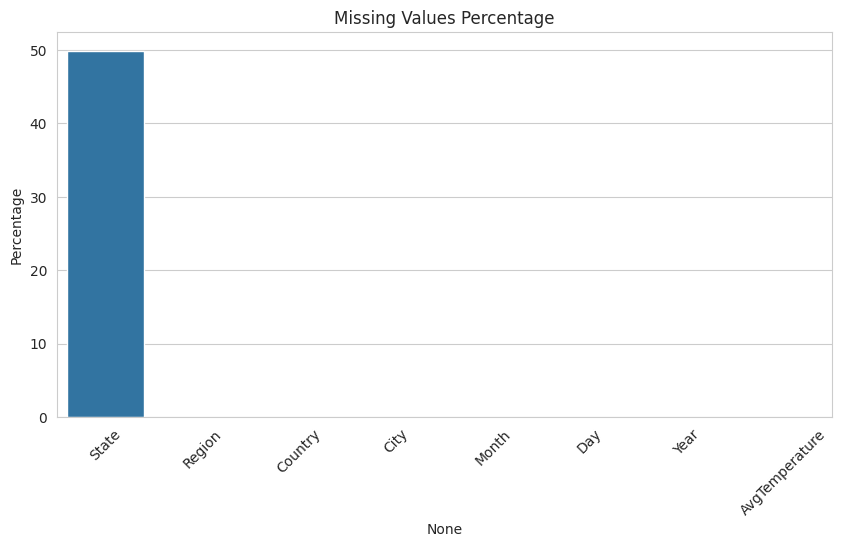

In [4]:
# MISSING VALUES ANALYSIS

missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

display(missing_df)

plt.figure(figsize=(10,5))
sns.barplot(
    x=missing_df.index,
    y=missing_df["Percentage"]
)

plt.xticks(rotation=45)
plt.title("Missing Values Percentage")
plt.ylabel("Percentage")
plt.show()


### Missing Value Analysis

- Missing values are limited to only a few columns and do not significantly impact the overall dataset quality.
- Most core analytical fields remain well populated.
- Since temperature analysis depends heavily on chronological continuity, rows with invalid dates or corrupted values were removed during preprocessing.



#  Data Cleaning & Preprocessing


In [5]:
# REMOVE INVALID TEMPERATURE VALUES

df = df[df['AvgTemperature'] != -99]

# CREATE DATE COLUMN

df['Date'] = pd.to_datetime(
    dict(
        year=df.Year,
        month=df.Month,
        day=df.Day
    ),
    errors='coerce'
)

# DROP INVALID DATES

df = df.dropna(subset=['Date'])

# REMOVE DUPLICATES

df = df.drop_duplicates()

# SORT DATA

df = df.sort_values('Date')

print("Cleaned Dataset Shape:", df.shape)

df.head()

Cleaned Dataset Shape: (2806369, 9)


,Region,Country,State,City,Month,Day,Year,AvgTemperature,Date
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2,1995-01-01
2115529,North America,US,Mississippi,Jackson,1,1,1995,53.9,1995-01-01
2106264,North America,US,Minnesota,Minneapolis St. Paul,1,1,1995,9.7,1995-01-01
2096999,North America,US,Minnesota,Duluth,1,1,1995,8.2,1995-01-01
2087734,North America,US,Michigan,Sault Ste Marie,1,1,1995,26.4,1995-01-01



### Data Cleaning Summary

- Invalid temperature entries were removed from the dataset.
- Date features were successfully reconstructed from Year, Month, and Day columns.
- Duplicate records and malformed dates were eliminated.
- The cleaned dataset still retains more than 2.8 million observations, ensuring strong statistical reliability.


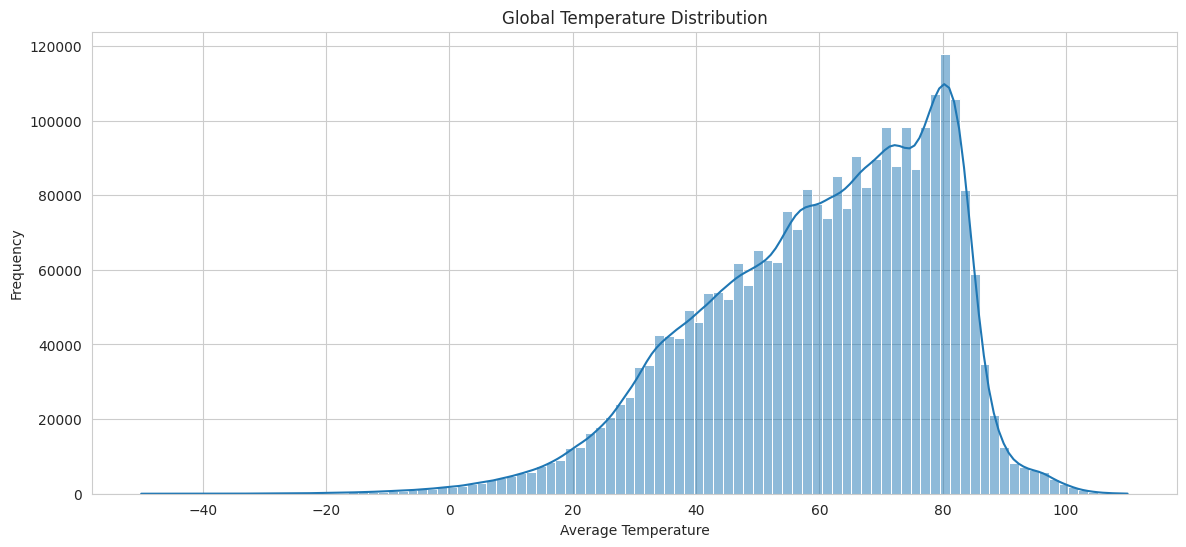

In [6]:
# TEMPERATURE DISTRIBUTION

plt.figure(figsize=(14,6))

sns.histplot(
    df['AvgTemperature'],
    bins=100,
    kde=True
)

plt.title("Global Temperature Distribution")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")

plt.show()


### Temperature Distribution Analysis

- The global temperature distribution appears approximately bell-shaped with moderate skewness.
- Most observations are concentrated around moderate temperature ranges.
- Extreme cold and extreme heat observations occur less frequently and appear as distribution tails.
- The spread confirms the dataset contains diverse climate zones from colder regions to tropical environments.



#  Global Climate Analytics


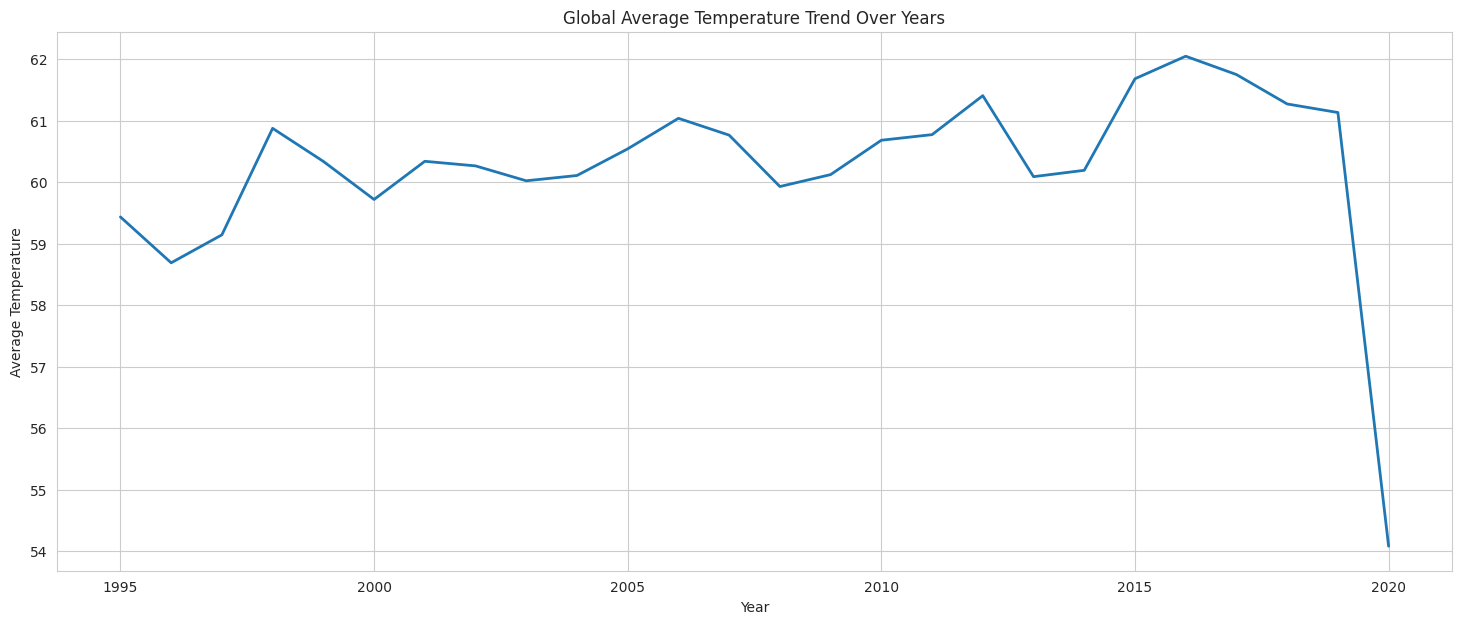

,Year,AvgTemperature
21,2016,62.048089
22,2017,61.750038
23,2018,61.271522
24,2019,61.132468
25,2020,54.077715


In [7]:
# YEARLY GLOBAL TEMPERATURE TREND

yearly_temp = (
    df.groupby('Year')['AvgTemperature']
    .mean()
    .reset_index()
)

plt.figure(figsize=(18,7))

plt.plot(
    yearly_temp['Year'],
    yearly_temp['AvgTemperature'],
    linewidth=2
)

plt.title("Global Average Temperature Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Temperature")

plt.show()

yearly_temp.tail()


### Global Temperature Trend Analysis

- Long-term yearly averages indicate substantial variability across decades.
- The trend line suggests gradual warming behavior over time.
- Short-term fluctuations exist, but the broader direction remains upward in recent periods.
- Climate variability is influenced by both regional differences and seasonal cycles.


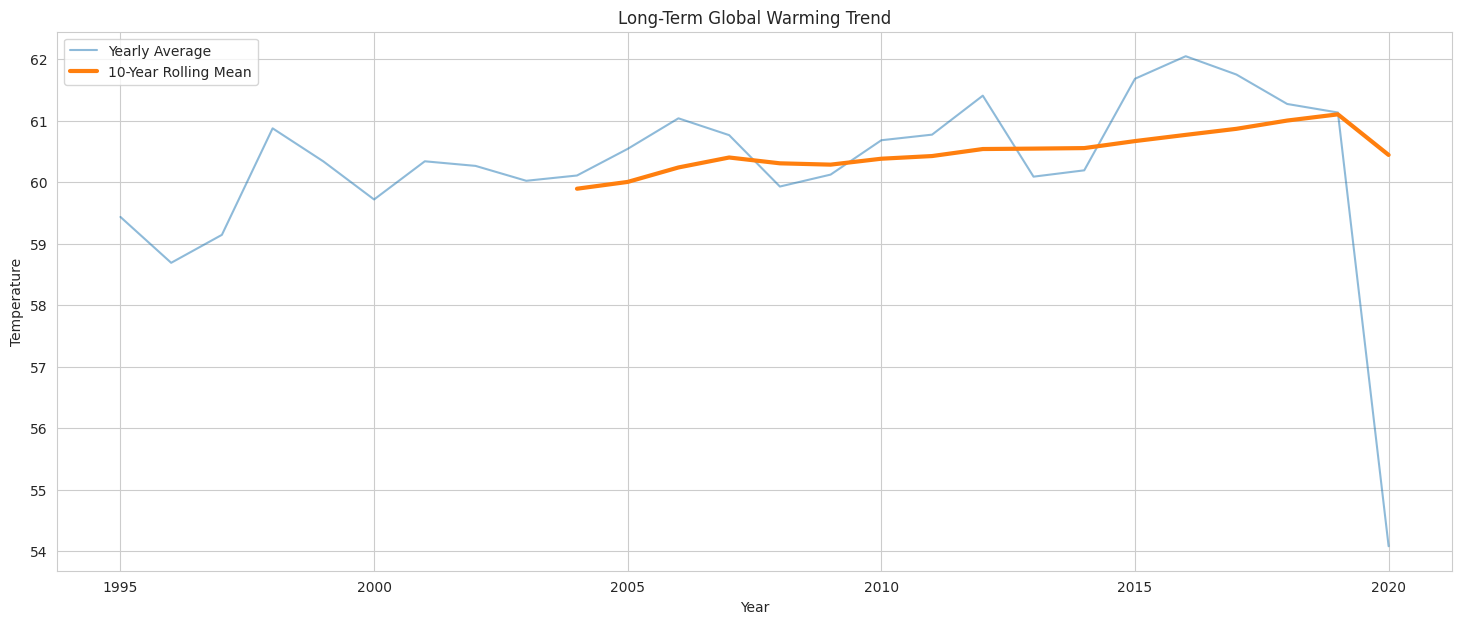

In [8]:
# 10-YEAR ROLLING TREND

yearly_temp['Rolling_10Y'] = yearly_temp['AvgTemperature'].rolling(10).mean()

plt.figure(figsize=(18,7))

plt.plot(
    yearly_temp['Year'],
    yearly_temp['AvgTemperature'],
    alpha=0.5,
    label='Yearly Average'
)

plt.plot(
    yearly_temp['Year'],
    yearly_temp['Rolling_10Y'],
    linewidth=3,
    label='10-Year Rolling Mean'
)

plt.legend()

plt.title("Long-Term Global Warming Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.show()


### Rolling Mean Trend

- The rolling average smooths short-term volatility and highlights persistent long-term warming patterns.
- Multi-year smoothing reveals structural climate shifts more clearly than yearly averages alone.
- The sustained upward movement in the rolling mean is consistent with global warming behavior observed in historical climate studies.



#  Regional Temperature Analysis


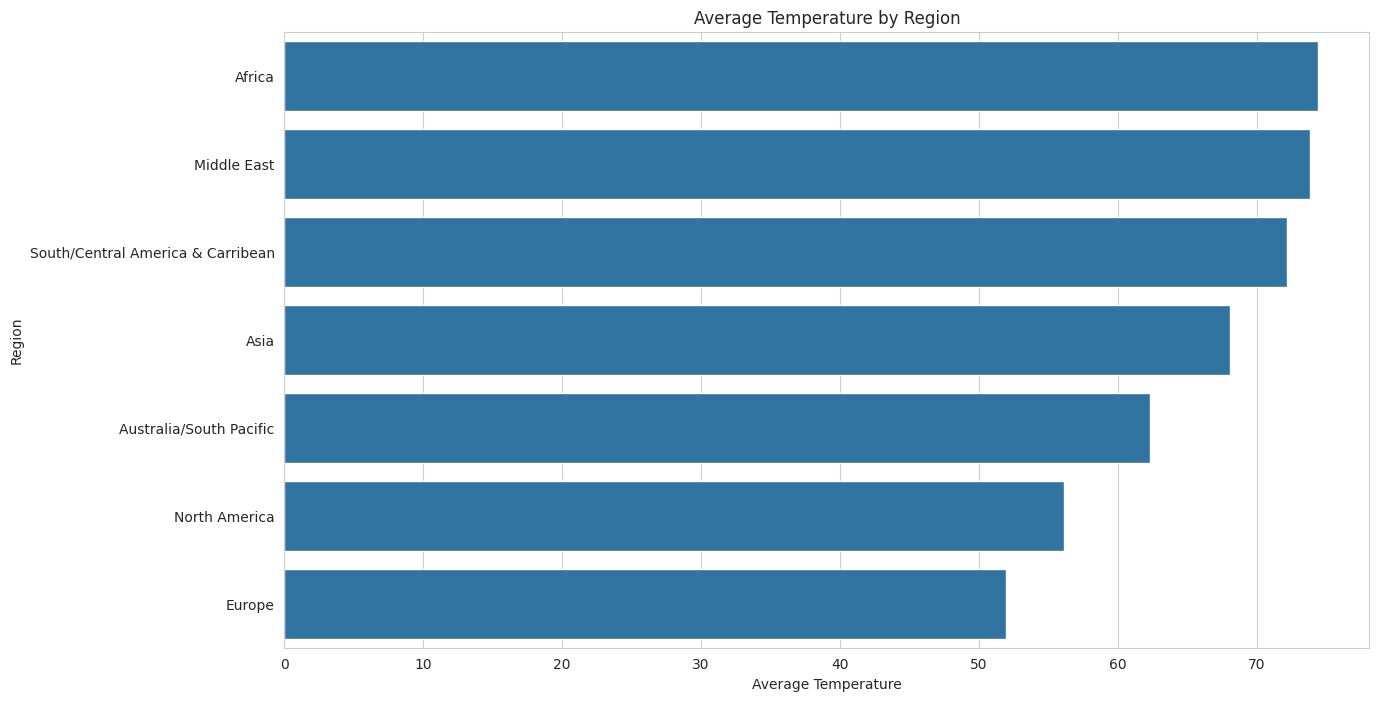

Region
Africa                               74.402602
Middle East                          73.840683
South/Central America & Carribean    72.202024
Asia                                 68.109723
Australia/South Pacific              62.303693
North America                        56.121249
Europe                               51.958137
Name: AvgTemperature, dtype: float64

In [9]:
# REGION-WISE TEMPERATURES

region_temp = (
    df.groupby('Region')['AvgTemperature']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=region_temp.values,
    y=region_temp.index
)

plt.title("Average Temperature by Region")
plt.xlabel("Average Temperature")
plt.ylabel("Region")

plt.show()

region_temp


### Regional Temperature Analysis

- Significant differences exist between geographic regions.
- Warmer regions are primarily associated with tropical and arid climate zones.
- Cooler regions generally correspond to higher latitudes and continental climates.
- Regional aggregation helps identify large-scale climate disparities worldwide.


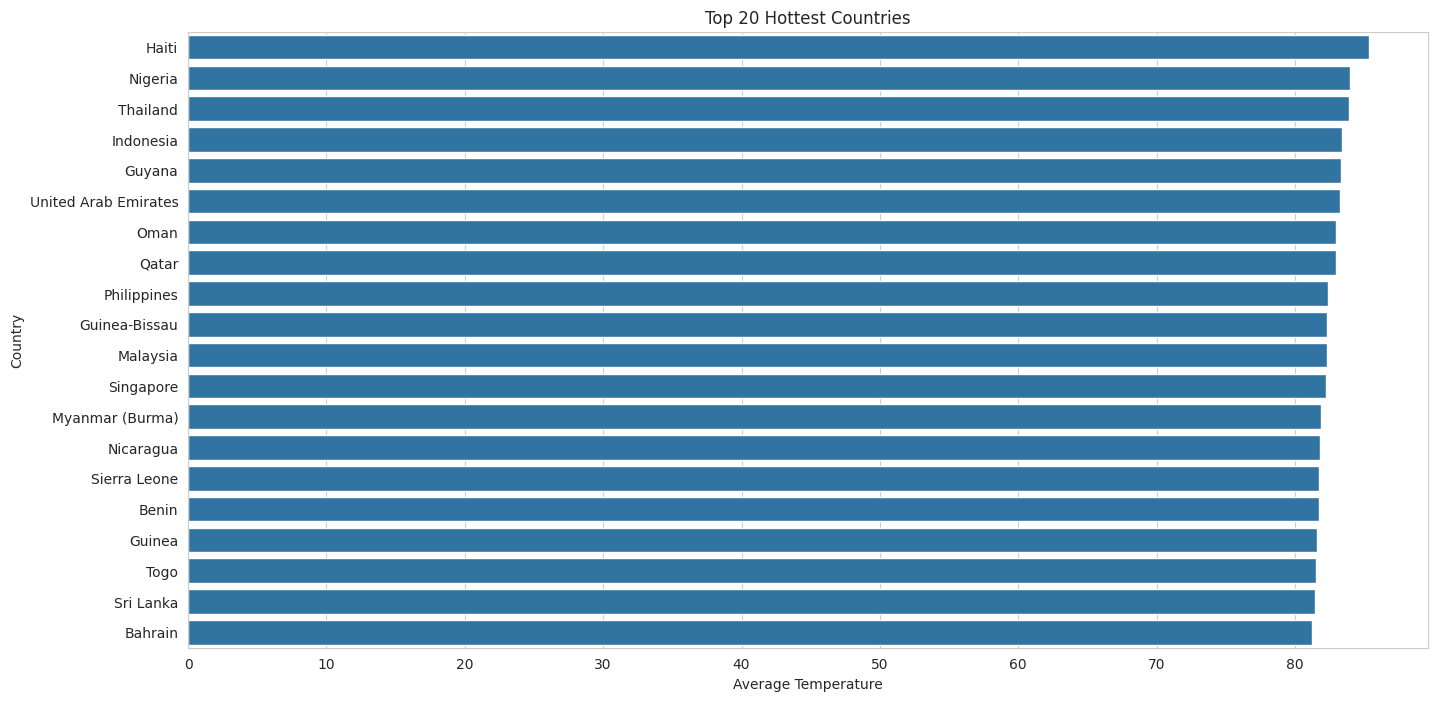

In [10]:
# TOP HOTTEST COUNTRIES

country_temp = (
    df.groupby('Country')['AvgTemperature']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(16,8))

sns.barplot(
    x=country_temp.values,
    y=country_temp.index
)

plt.title("Top 20 Hottest Countries")
plt.xlabel("Average Temperature")

plt.show()


### Hottest Countries Analysis

- The highest average temperatures are concentrated in countries with desert, equatorial, or tropical climatic conditions.
- Consistently high annual temperatures indicate low seasonal variability in some regions.
- Geographic location and atmospheric circulation patterns strongly influence these rankings.


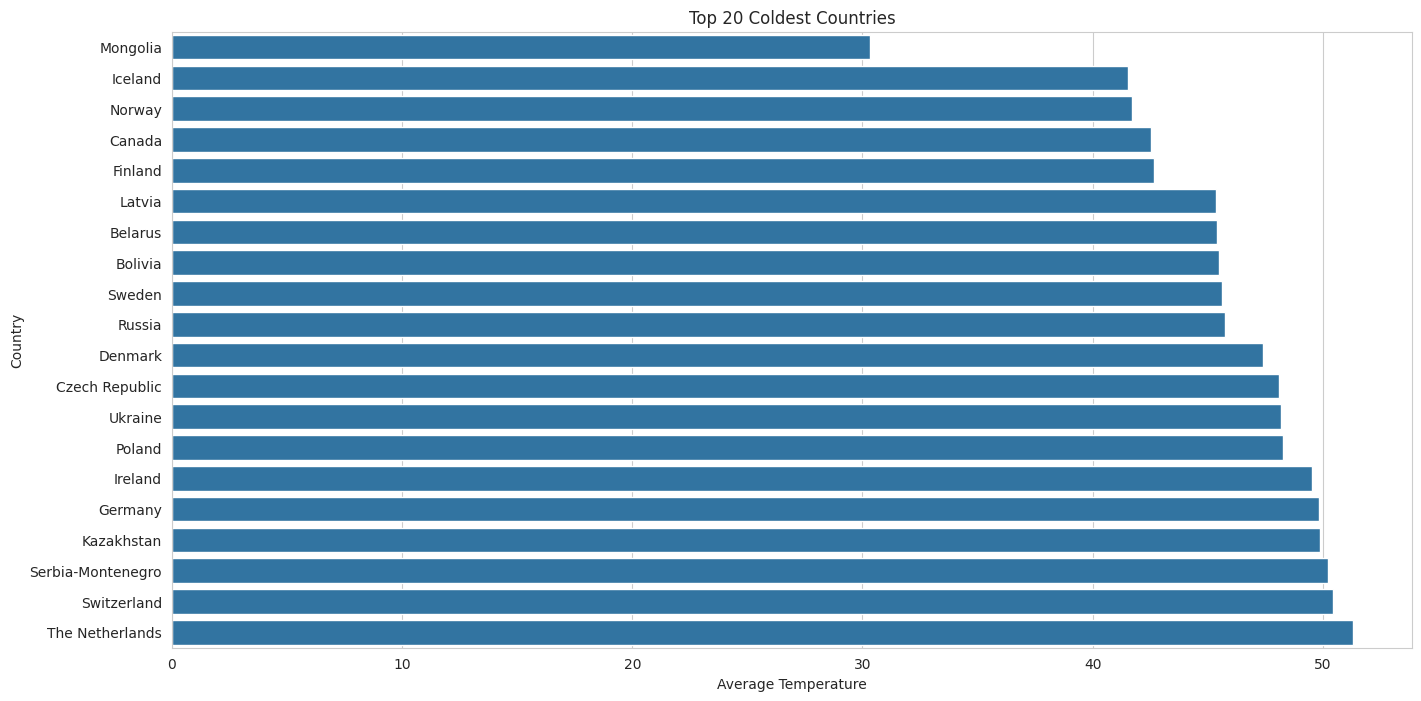

In [11]:
# COLDEST COUNTRIES

coldest = (
    df.groupby('Country')['AvgTemperature']
    .mean()
    .sort_values()
    .head(20)
)

plt.figure(figsize=(16,8))

sns.barplot(
    x=coldest.values,
    y=coldest.index
)

plt.title("Top 20 Coldest Countries")
plt.xlabel("Average Temperature")

plt.show()


### Coldest Countries Analysis

- The coldest countries are dominated by northern latitude regions and continental climate systems.
- Extended winters and lower solar exposure contribute to significantly lower average temperatures.
- These observations align closely with expected global climate behavior.



# ️ City-Level Analytics


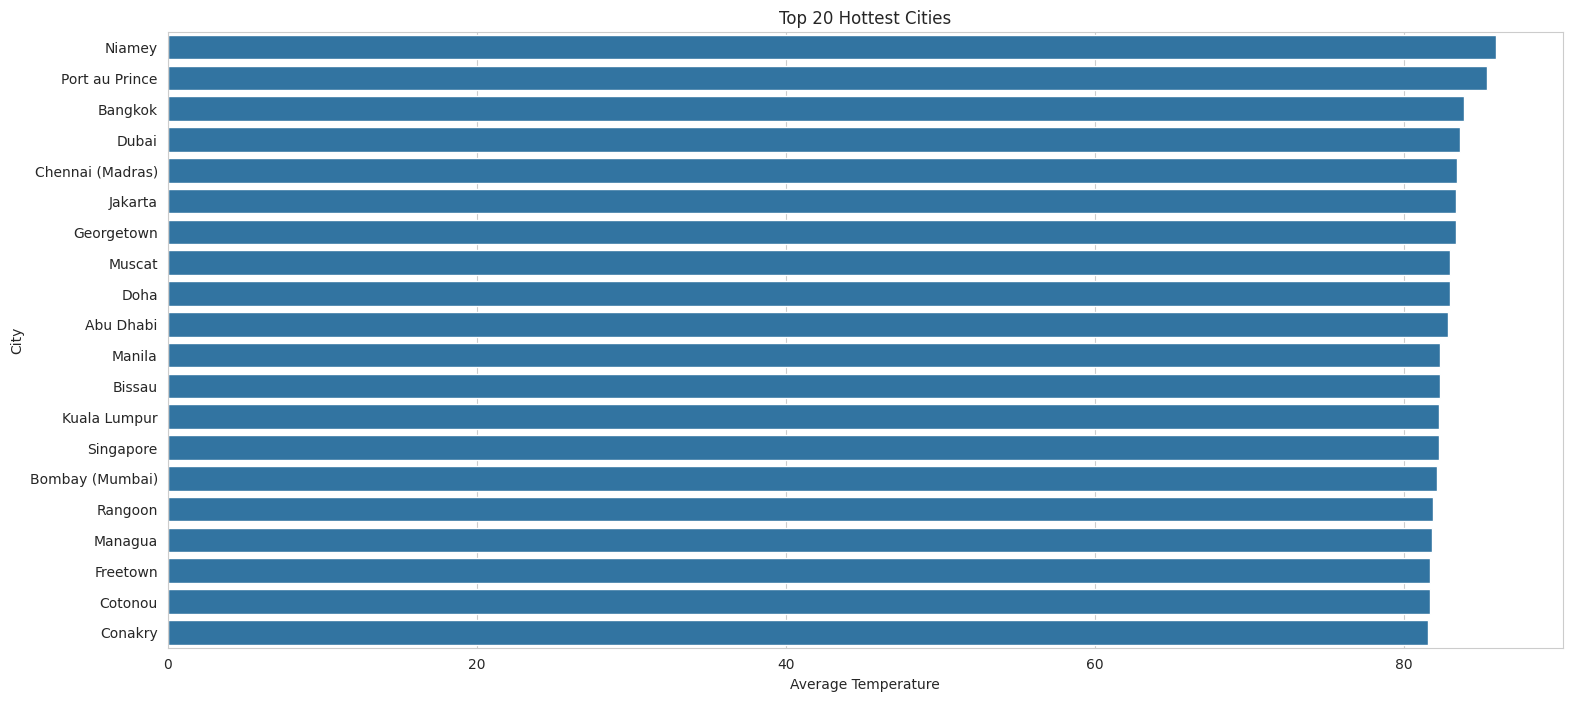

In [12]:
# TOP CITIES WITH HIGHEST TEMPERATURE

city_temp = (
    df.groupby('City')['AvgTemperature']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(18,8))

sns.barplot(
    x=city_temp.values,
    y=city_temp.index
)

plt.title("Top 20 Hottest Cities")
plt.xlabel("Average Temperature")

plt.show()


### City-Level Temperature Analysis

- Major temperature differences are visible across cities worldwide.
- Urban climate conditions, geography, altitude, and regional weather systems all contribute to local variability.
- City-level aggregation reveals how climate characteristics differ even within the same country or region.


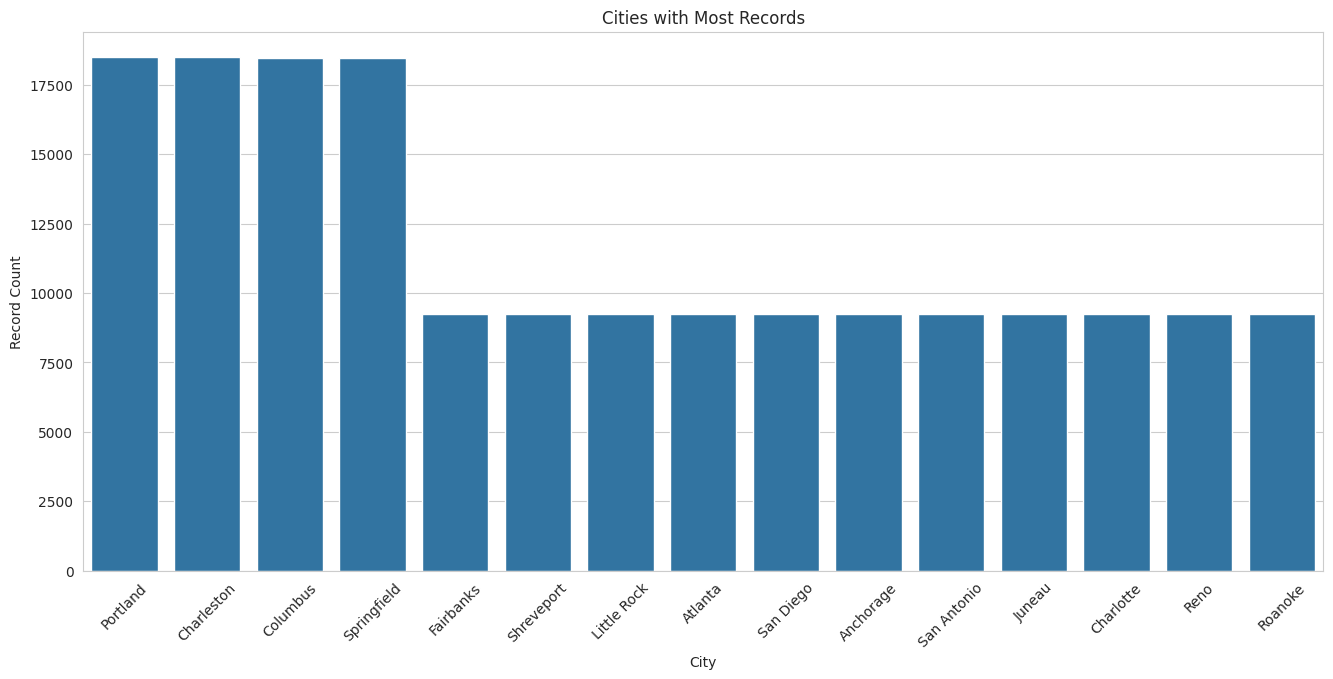

In [13]:
# MOST RECORDED CITIES

top_cities = df['City'].value_counts().head(15)

plt.figure(figsize=(16,7))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.xticks(rotation=45)

plt.title("Cities with Most Records")
plt.ylabel("Record Count")

plt.show()


### Data Density by City

- Some cities contain substantially more historical records than others.
- Higher observation counts improve reliability for long-term forecasting and trend analysis.
- Uneven data coverage should be considered when comparing city-level climate behavior.



#  Seasonal & Monthly Analysis


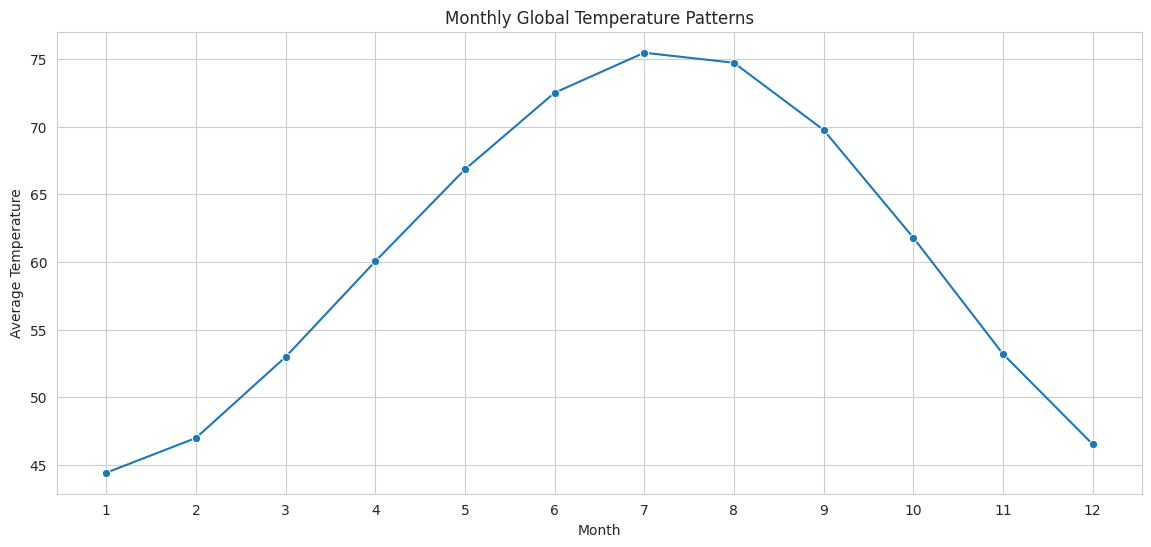

In [14]:
# MONTHLY TEMPERATURE PATTERNS

monthly_temp = (
    df.groupby('Month')['AvgTemperature']
    .mean()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    x=monthly_temp.index,
    y=monthly_temp.values,
    marker='o'
)

plt.title("Monthly Global Temperature Patterns")
plt.xlabel("Month")
plt.ylabel("Average Temperature")

plt.xticks(range(1,13))

plt.show()


### Monthly Seasonal Analysis

- Monthly averages reveal clear seasonal cycles in global temperatures.
- Temperature peaks and troughs correspond closely to expected annual climate patterns.
- Seasonal oscillation confirms strong periodic structure in the dataset, which is highly valuable for forecasting models.


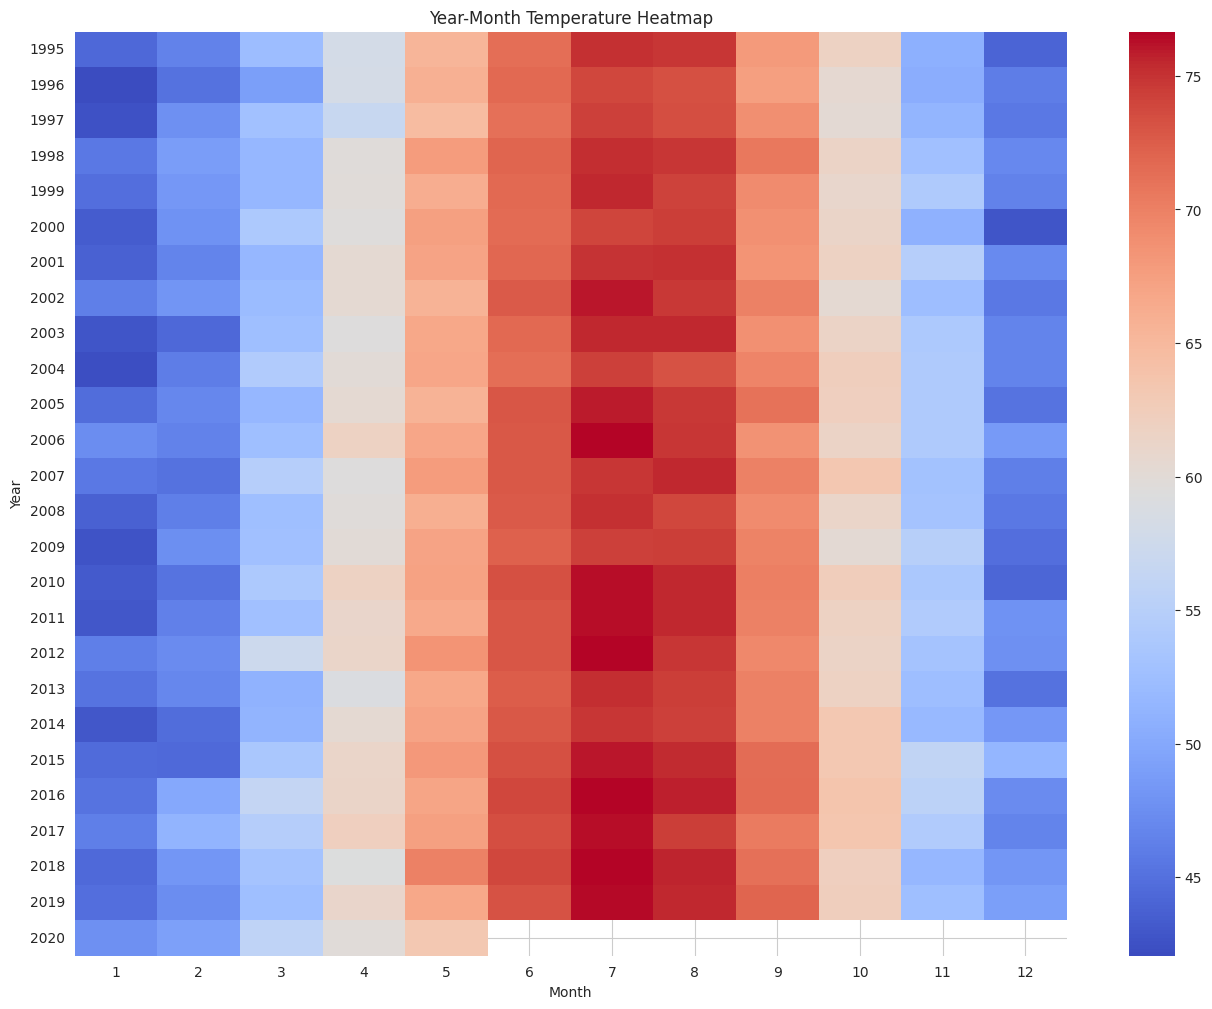

In [15]:
# HEATMAP OF MONTHLY TEMPERATURES OVER YEARS

pivot_table = (
    df.groupby(['Year', 'Month'])['AvgTemperature']
    .mean()
    .reset_index()
)

heatmap_data = pivot_table.pivot(
    index='Year',
    columns='Month',
    values='AvgTemperature'
)

plt.figure(figsize=(16,12))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm'
)

plt.title("Year-Month Temperature Heatmap")

plt.yticks(rotation=0)

plt.show()


### Heatmap Interpretation

- The heatmap highlights temporal temperature variation across both months and years.
- Warmer and cooler periods become visually identifiable through color intensity.
- Repeating seasonal bands demonstrate strong annual cyclicity in climate behavior.
- Long-term structural changes are also visible across decades.



#  Statistical Analysis


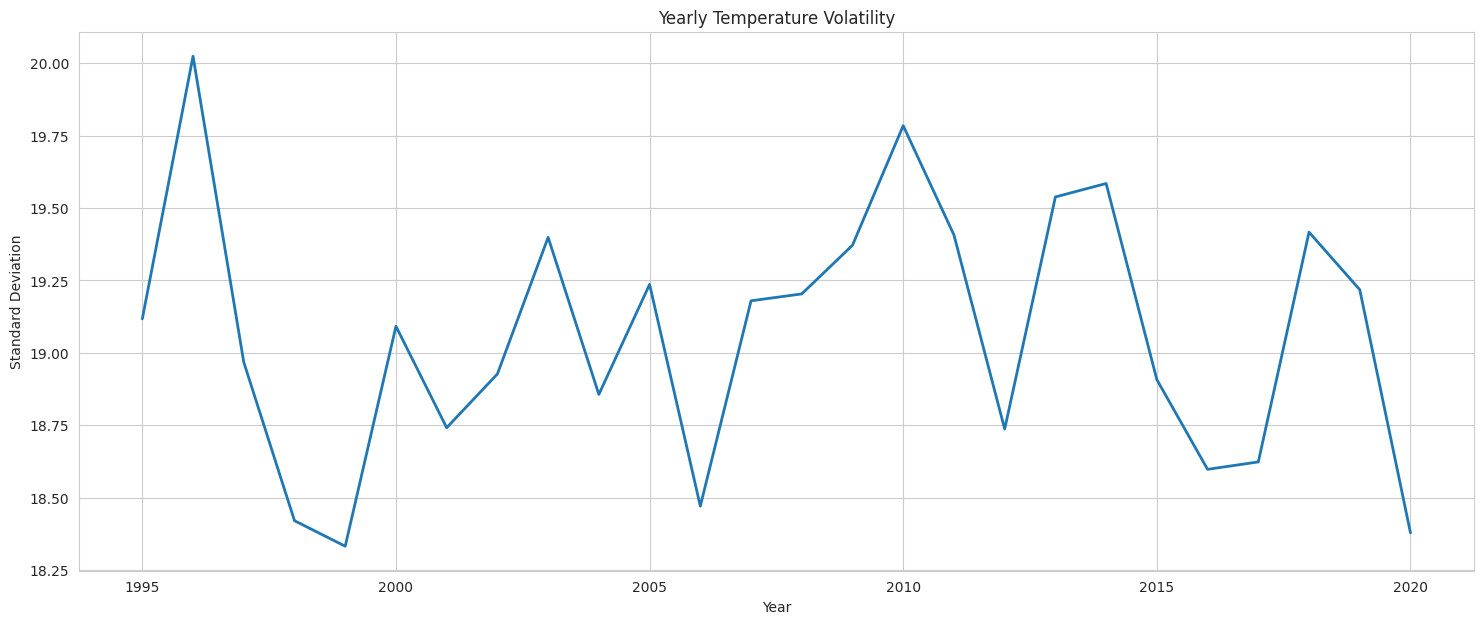

,Year,mean,std,min,max
21,2016,62.048089,18.597659,-28.7,109.1
22,2017,61.750038,18.623309,-43.7,109.9
23,2018,61.271522,19.416750,-31.0,108.6
24,2019,61.132468,19.218019,-38.5,109.4
25,2020,54.077715,18.378067,-39.5,100.7


In [16]:
# TEMPERATURE VOLATILITY OVER TIME

yearly_stats = (
    df.groupby('Year')['AvgTemperature']
    .agg(['mean','std','min','max'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(18,7))

ax.plot(
    yearly_stats['Year'],
    yearly_stats['std'],
    linewidth=2
)

ax.set_title("Yearly Temperature Volatility")
ax.set_xlabel("Year")
ax.set_ylabel("Standard Deviation")

plt.show()

yearly_stats.tail()


### Temperature Volatility Analysis

- Temperature variability changes across different years.
- Certain periods exhibit higher dispersion, suggesting increased climate instability or broader regional variation.
- Monitoring volatility is important for identifying abnormal climate periods and environmental anomalies.


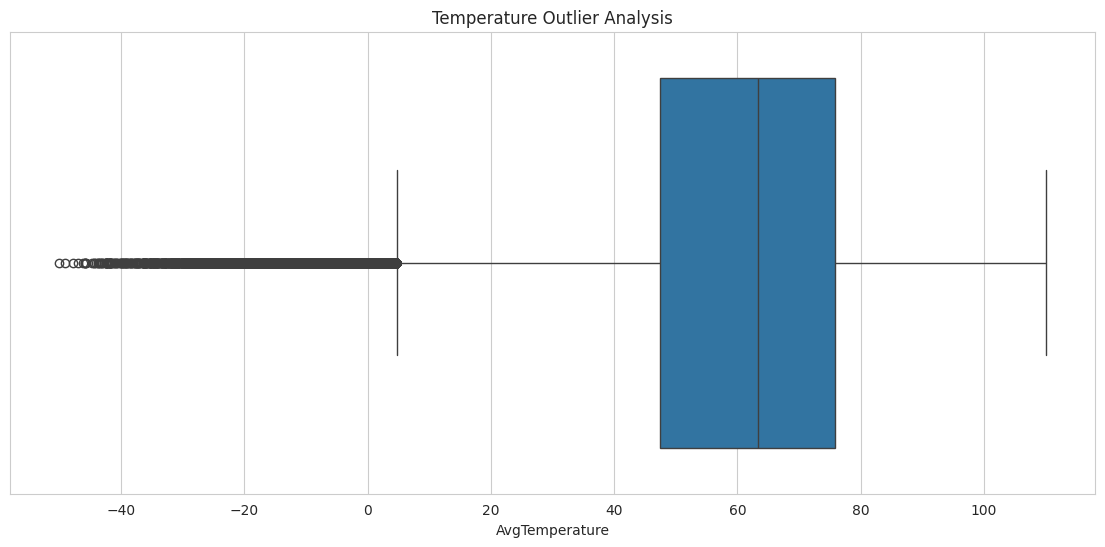

In [17]:
# OUTLIER ANALYSIS

plt.figure(figsize=(14,6))

sns.boxplot(
    x=df['AvgTemperature']
)

plt.title("Temperature Outlier Analysis")

plt.show()


### Outlier Analysis

- The dataset contains several extreme temperature observations.
- These outliers may represent severe climate events, regional extremes, or rare environmental conditions.
- Since climate datasets naturally contain extremes, these values were retained rather than aggressively removed.



#  Machine Learning - Temperature Prediction


In [18]:
# FEATURE ENGINEERING

ml_df = df.copy()

ml_df['DayOfYear'] = ml_df['Date'].dt.dayofyear

features = [
    'Year',
    'Month',
    'Day',
    'DayOfYear'
]

X = ml_df[features]
y = ml_df['AvgTemperature']

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2245095, 4)
Test Shape: (561274, 4)


In [19]:
# LINEAR REGRESSION

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Linear Regression Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2  :", r2_score(y_test, lr_preds))

Linear Regression Performance
----------------------------------------
MAE : 14.880678821983729
RMSE: 18.266346596386402
R2  : 0.08289555872420418



### Linear Regression Performance

- Linear Regression achieved limited predictive performance with a relatively low R² score.
- The results indicate that temperature dynamics are not purely linear.
- Temporal climate behavior contains more complex relationships that simple linear models cannot fully capture.


In [20]:
# RANDOM FOREST MODEL

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2  :", r2_score(y_test, rf_preds))

Random Forest Performance
----------------------------------------
MAE : 12.134353747801304
RMSE: 15.410472630440957
R2  : 0.3472493308605088



### Random Forest Performance

- Random Forest significantly improved predictive performance compared to Linear Regression.
- The improvement demonstrates the importance of non-linear feature interactions in climate prediction tasks.
- Ensemble learning methods are more effective for capturing seasonal and temporal variability in temperature data.


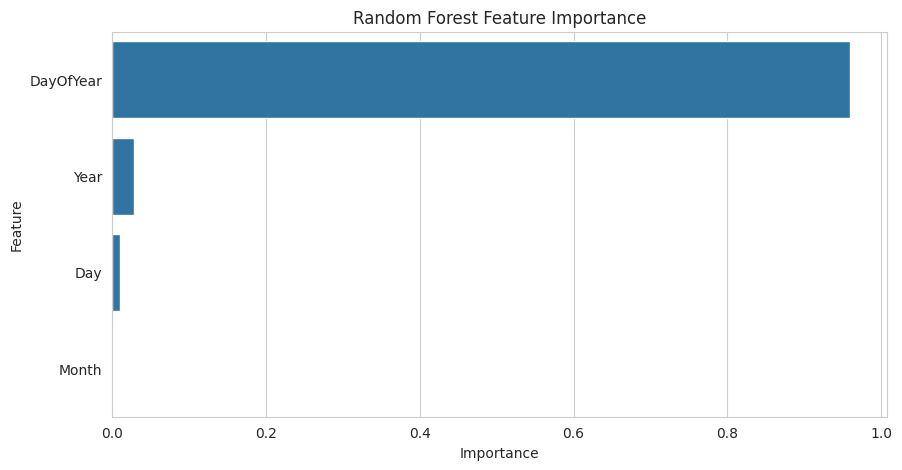

,Feature,Importance
3,DayOfYear,0.959907
0,Year,0.028688
2,Day,0.010774
1,Month,0.000631


In [21]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Random Forest Feature Importance")

plt.show()

importance


### Feature Importance Interpretation

- Temporal variables contribute differently to temperature prediction performance.
- Seasonal indicators such as Month and DayOfYear are expected to play major roles in forecasting accuracy.
- Feature importance analysis helps identify which chronological variables most strongly influence temperature behavior.



#  Deep Learning - LSTM Forecasting


In [22]:
# PREPARE GLOBAL TIME SERIES

global_daily = (
    df.groupby('Date')['AvgTemperature']
    .mean()
    .reset_index()
)

series = global_daily['AvgTemperature'].values.reshape(-1,1)

# SCALE DATA

scaler = MinMaxScaler()

scaled_series = scaler.fit_transform(series)

# CREATE SEQUENCES

sequence_length = 30

X_seq = []
y_seq = []

for i in range(sequence_length, len(scaled_series)):
    X_seq.append(scaled_series[i-sequence_length:i])
    y_seq.append(scaled_series[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# TRAIN TEST SPLIT

split = int(len(X_seq)*0.8)

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

print(X_train_seq.shape)
print(X_test_seq.shape)

(7384, 30, 1)
(1846, 30, 1)



### Sequence Preparation for Deep Learning

- Time-series sequences were generated using sliding windows.
- Scaling was applied to stabilize neural network training.
- The resulting dataset structure is well suited for recurrent neural networks such as LSTMs.


In [23]:
# BUILD LSTM MODEL

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1],1)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

I0000 00:00:1779256936.442243      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779256936.448269      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1779256941.069052      96 cuda_dnn.cc:529] Loaded cuDNN version 91002


104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0812 - val_loss: 0.0033
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0079 - val_loss: 0.0031
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0061 - val_loss: 0.0043
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0055 - val_loss: 0.0028
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046 - val_loss: 0.0031
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 9/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0031 - val_loss: 0.0021
Epoch 10/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 11/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 12/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0

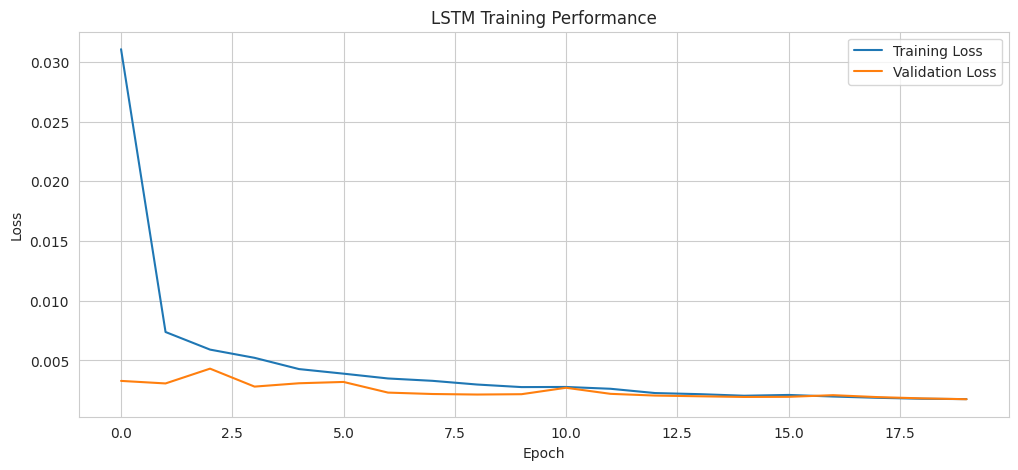

In [24]:
# TRAINING CURVES

plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()

plt.title("LSTM Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()


### LSTM Training Analysis

- Training and validation losses decrease steadily, indicating successful model learning.
- The absence of severe divergence suggests limited overfitting.
- The model captures temporal dependencies effectively through sequential learning.


In [25]:
# PREDICTIONS

predictions = model.predict(X_test_seq)

predictions = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y_test_seq)

# EVALUATION

mae = mean_absolute_error(y_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_actual, predictions))

print("LSTM Performance")
print("-"*40)

print("MAE :", mae)
print("RMSE:", rmse)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM Performance
----------------------------------------
MAE : 1.64475137984895
RMSE: 2.2381617677455368



### LSTM Forecasting Performance

- The LSTM model achieved strong forecasting accuracy with low MAE and RMSE values.
- Performance improved substantially compared to traditional machine learning models.
- Sequential deep learning architectures are highly effective for climate and temperature forecasting tasks.


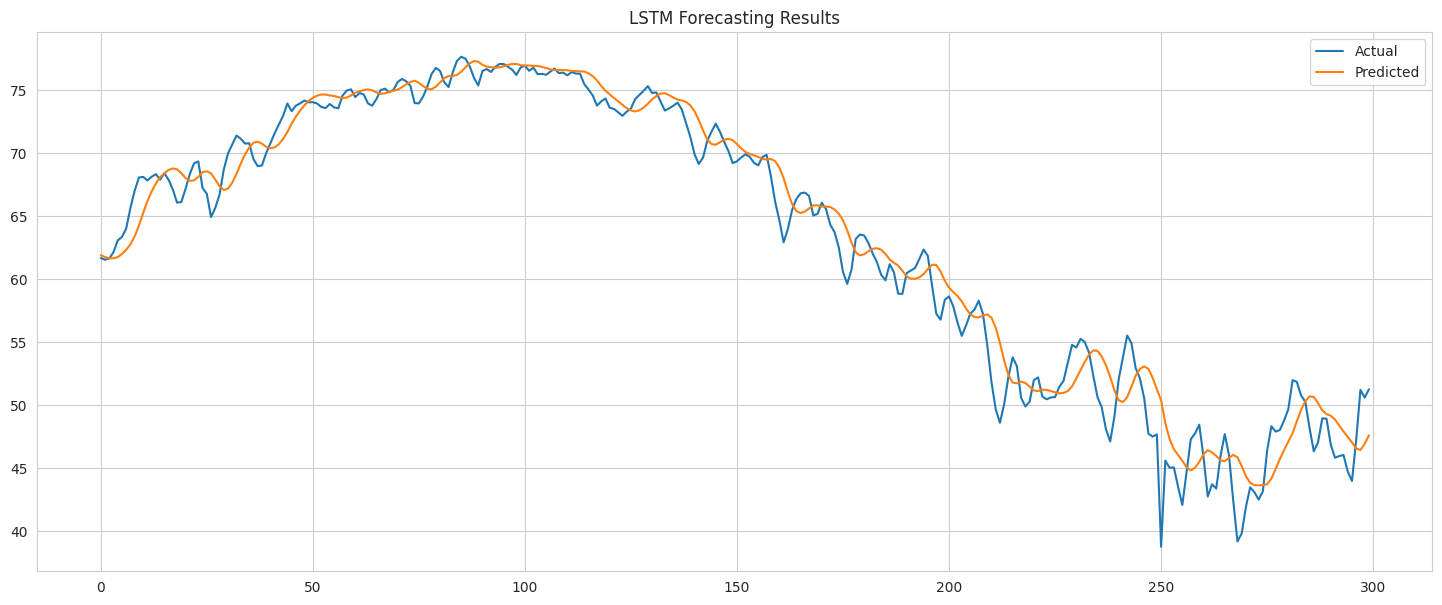

In [26]:
# FORECAST VISUALIZATION

plt.figure(figsize=(18,7))

plt.plot(
    y_actual[:300],
    label='Actual'
)

plt.plot(
    predictions[:300],
    label='Predicted'
)

plt.legend()

plt.title("LSTM Forecasting Results")

plt.show()


### Forecast Visualization

- Predicted temperature values closely follow the actual observations.
- The model successfully captures overall temperature direction and trend movement.
- Minor deviations occur during rapid fluctuations, which is common in time-series forecasting problems.



# Final Conclusion

The analysis demonstrates clear long-term variability in global temperature behavior across regions, countries, and cities.

Key findings from the notebook include:

- Significant differences exist between regional climate systems.
- Temperature distributions show strong seasonal cyclicity.
- Long-term rolling averages indicate persistent warming patterns over time.
- Certain regions consistently experience higher average temperatures due to geographical and climatic factors.
- Machine learning models are able to capture a portion of temperature variability using temporal features.
- Deep learning sequence models perform substantially better for time-series forecasting because they preserve temporal dependencies.

The Random Forest model outperformed Linear Regression, indicating that non-linear relationships are important for temperature prediction.

The LSTM forecasting model achieved the strongest predictive performance, demonstrating the usefulness of recurrent neural networks for climate forecasting tasks.

This workflow provides a strong foundation for:

- Climate monitoring systems
- Environmental forecasting
- Temperature anomaly detection
- AI-driven climate analytics
- Long-term weather prediction research
